In [14]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *

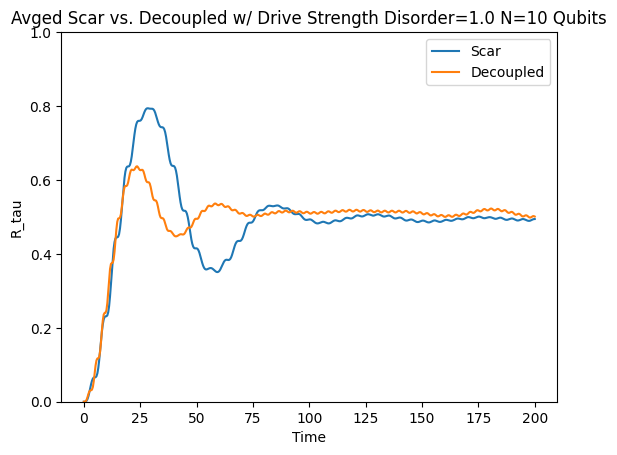

In [15]:
wd = 0.6365091993031
tlist = np.linspace(0, 200, 500)
N = 10
d = 1.0
reals = 100

Rtau_scar = np.zeros(len(tlist))
args = {"A": 0.1, "omega": wd}
for _ in range(reals):
    H0, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N, random_seed=True, ds_dis=d)
    H = qt.QobjEvo([H0, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
    Rtau = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / (eigenvalues[-1] - eigenvalues[0]))
    Rtau_scar += Rtau
Rtau_scar = Rtau_scar / reals

Rtau_qubit = np.zeros(len(tlist))
qargs = {"A": 0.1, "omega": 1.0}
for _ in range(reals):
    H0, H1, eigenvalues, eigenstates = get_qubit_ham(N, random_seed=True, ds_dis=d)
    H = qt.QobjEvo([H0, [H1, coeff]], args=qargs)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
    Rtau = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / (eigenvalues[-1] - eigenvalues[0]))
    Rtau_qubit += Rtau
Rtau_qubit = Rtau_qubit / reals

plt.title(f"Avged Scar vs. Decoupled w/ Drive Strength Disorder={d} N={N} Qubits")
plt.ylabel("R_tau")
plt.xlabel("Time")
plt.ylim(0, 1)
plt.plot(tlist, Rtau_scar, label="Scar")
plt.plot(tlist, Rtau_qubit, label="Decoupled")
plt.legend()
plt.show()